In [2]:
import math
import numpy
import camera_setup as cs
import json
import random
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [3]:
robot_coords = []
cam_coords = []
files = ["robo_coords.txt", "saved_coordinates.txt"]

for i in files:
    with open(i, "r") as f:
        if i == "robo_coords.txt":
            lines = f.readlines()
            for i in lines:
                x = json.loads(i)
                robot_coords.append(x)
        
        else:
            lines = f.readlines()
            for i in lines:
                x = json.loads(i)
                cam_coords.append(x)

print(robot_coords)
print(cam_coords)

[[551.255, 30.4549, -44.9023], [515.537, -196.268, -43.1387], [273.764, -196.429, -39.5692], [523.496, 174.052, -45.0883], [380.401, -209.621, -36.971], [203.086, -223.181, -38.7565], [509.772, 36.445, -50.9596], [276.305, -21.3069, -38.6157], [400.672, 212.686, -40.2759], [406.959, -231.356, -38.1634], [470.043, 207.363, -45.4265], [304.793, 305.003, -41.4565], [385.001, -12.2891, -54.6942], [205.262, 3.93179, -57.6336], [416.311, -213.356, -48.4041], [534.322, -5.74047, -41.57], [426.716, 229.902, -37.3286], [204.95, 345.379, -77.5168], [542.387, -39.571, -44.1623], [520.879, 328.839, -37.6339], [440.33, -207.238, -42.5005], [231.206, -201.455, -39.1405], [391.508, 234.471, -37.3575], [155.306, 38.3378, -85.9361], [169.847, 318.745, -85.2682], [277.234, -126.764, -53.354], [409.887, 201.838, -43.3455], [274.899, 96.9987, -38.3193], [548.39, -89.0096, -47.9837], [394.163, 360.014, -45.2465], [598.309, 95.9621, -44.5715], [447.773, -180.738, -46.3767], [318.486, 198.147, -37.1672], [28

In [9]:
count = 3
standard_deviation_list = []
mean_value_list = []
best_rms_list = []
worst_rms_list = []

while count <= len(robot_coords)-1:
    robot_combinations = []
    cam_combinations = []
    index_list = []
    rms_error_list = []
    
    best_rms = math.inf
    worst_rms = 0
    i = 0
    while i < 5000:
        dummy_robot_list = []
        dummy_cam_list = []
        element_list = []
        while len(element_list) <= count:
            rand_index = random.randint(0,len(robot_coords))
            if rand_index not in element_list:
                element_list.append(rand_index)
        if element_list not in index_list:
            index_list.append(element_list)
            for element in element_list:
                dummy_robot_list.append(robot_coords[element])
                dummy_cam_list.append(cam_coords[element])
            cam_combinations.append(dummy_cam_list)
            robot_combinations.append(dummy_robot_list)
            i += 1
    #print(robot_combinations)
    for i in range(len(cam_combinations)):
        rot,trans =cs.estimate_rigid_transform(cam_combinations[i], robot_combinations[i])
        rms_error = cs.rms_alignment_error(cam_combinations[i], robot_combinations[i], rot, trans)
        rms_error_list.append(rms_error)
        if rms_error < best_rms:
            best_rms = rms_error
            best_rms_index = i
        if rms_error > worst_rms:
            worst_rms = rms_error
            worst_rms_index = i 
    mean_value = numpy.mean(rms_error_list)
    standard_deviation = numpy.std(rms_error_list)
    mean_value_list.append(mean_value)
    standard_deviation_list.append(standard_deviation)
    best_rms_list.append(best_rms)
    worst_rms_list.append(worst_rms)
    print(f"Num_positions:{count}\n Worst RMS:{worst_rms}\n Worst RMS Index:{worst_rms_index}\n Mean RMS: {mean_value}\n Std Deviation: {standard_deviation}\n")
    count += 1
    

IndexError: list index out of range

In [5]:
print(best_rms_list)
print(worst_rms_list)
print(standard_deviation_list)
print(mean_value_list)

[0.6470351222527151, 1.828017265398558, 3.581928392817405, 4.803946991502435, 5.749471224571633, 6.842866816528562, 6.278248003169533, 7.465313557243612, 9.78750765934639, 9.894395947103982, 10.469161059368782, 11.150158687497912, 11.327943382571664, 11.753843410292674, 11.867197462581595, 12.30498033711102, 12.757854441216839, 12.268745510154888, 12.870728738610898, 13.275041113516513, 13.01604771750942, 13.027589385544465, 13.614590385027073, 13.639826473216141, 13.780750675096101, 14.17916859998271, 14.37200884212639, 14.38297840434271, 14.889947722232545, 14.58130193979283, 14.736511958039605, 15.013063651800502, 15.304616450014656, 15.406670261492708, 15.49476420279116, 16.174588136022628, 16.73270024002742, 17.477725559308386]
[26.441045861973727, 24.668626732915165, 24.48959804646399, 22.78584485718508, 23.797139731263535, 23.46087941055019, 23.495607675862427, 22.838082103832484, 22.26784178564273, 21.722892426117284, 21.941616967902846, 21.271725991620745, 21.193348038335, 21.

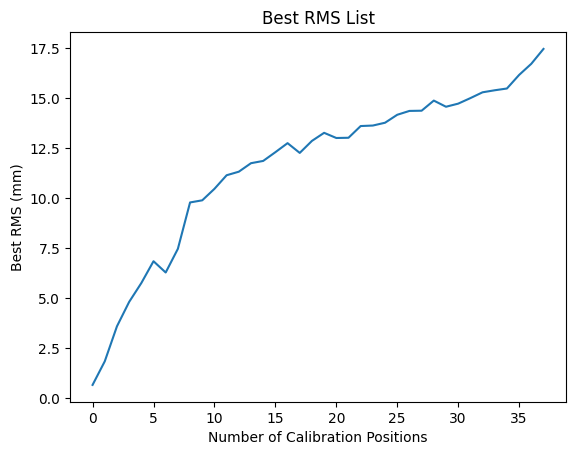

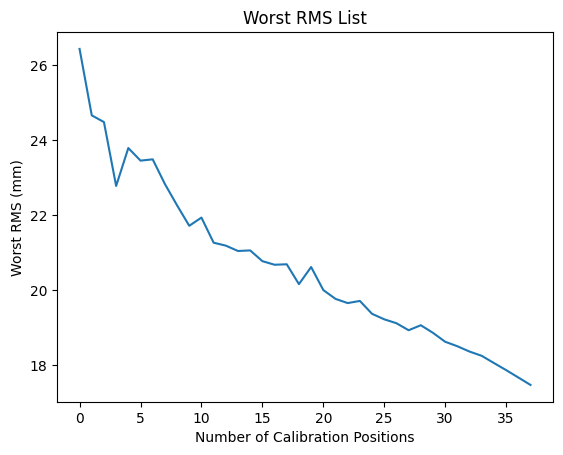

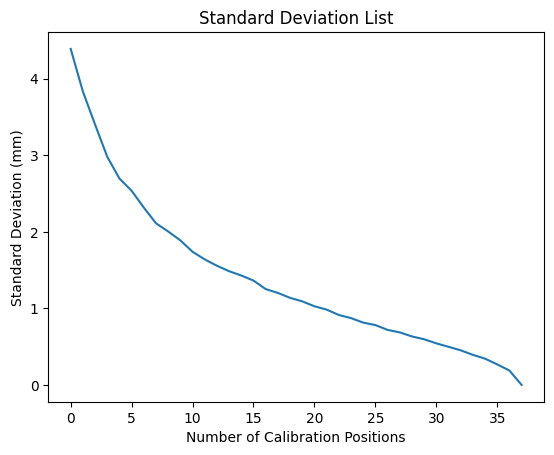

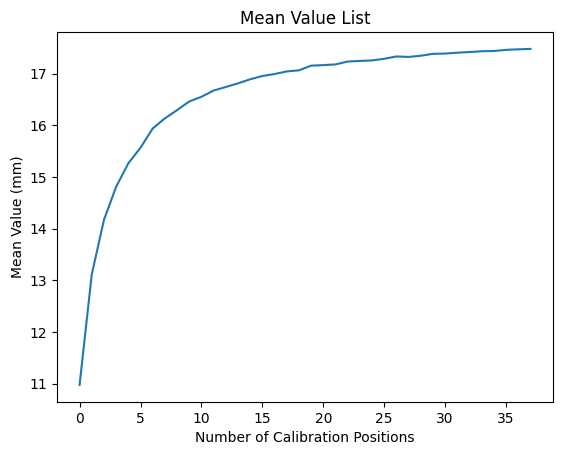

In [6]:
# ---- Plot 1: Best RMS ----
plt.figure()
plt.plot(best_rms_list)
plt.title("Best RMS List")
plt.xlabel("Number of Calibration Positions")
plt.ylabel("Best RMS (mm)")
plt.show()

# ---- Plot 2: Worst RMS ----
plt.figure()
plt.plot(worst_rms_list)
plt.title("Worst RMS List")
plt.xlabel("Number of Calibration Positions")
plt.ylabel("Worst RMS (mm)")
plt.show()

# ---- Plot 3: Standard Deviation ----
plt.figure()
plt.plot(standard_deviation_list)
plt.title("Standard Deviation List")
plt.xlabel("Number of Calibration Positions")
plt.ylabel("Standard Deviation (mm)")
plt.show()

# ---- Plot 4: Mean Value ----
plt.figure()
plt.plot(mean_value_list)
plt.title("Mean Value List")
plt.xlabel("Number of Calibration Positions")
plt.ylabel("Mean Value (mm)")
plt.show()